In [19]:
import os
import pickle
import numpy as np
import pandas as pd
from pprint import pprint
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches
from scipy.stats.mstats import winsorize

plt.rcParams.update({'font.size': 12})

In [20]:
def from_pickle(filename):
    with open(filename, "rb") as file:
        return pickle.load(file)

In [21]:
models = ['WDRBO3', 'SBOKDE', 'UCB', 'WassersteinUCB', 'EmpiricalUCB', 'DRBOKDE', 'Stable', 'MMD', 'MMD_Minimax_Approx']

In [22]:
functions = ['ThreeHumpCamel', 'SixHumpCamel', 'Ackley',
             'Hartmann', 'Hartmann_complicated', 'Modified_Branin' ,
             'Continuous_Vendor','portfolio_optimization', 'portfolio_normal_optimization']

In [23]:
name_to_title = {
     'ThreeHumpCamel': 'Three-Hump Camel' ,
     'Ackley': 'Ackley',
     'Hartmann': 'Hartmann',
     'Modified_Branin': 'Modified Branin',
     'portfolio_optimization': 'Portfolio (Uniform)',
     'portfolio_normal_optimization': 'Portfolio (Normal)',
     'Continuous_Vendor': 'Newsvendor',
     'SixHumpCamel': 'Six-Hump Camel',
     'Hartmann_complicated': 'Hartmann (Complicated)'
}

In [24]:
method_to_name = {
    'WDRBO3': 'EDRBO (Ours)',
    'SBOKDE': 'SBO-KDE',
    'UCB': 'UCB',
    'WassersteinUCB': 'WDRBO',
    'EmpiricalUCB': 'ERBO',
    'DRBOKDE': 'DRBO-KDE',
    'Stable': 'StableOpt',
    'MMD': 'DRBO-MMD',
    'MMD_Minimax_Approx': 'DRBO-MMD Minmax'
}

In [25]:
res = dict.fromkeys(functions)

In [26]:
for f in res.keys():
    res[f] = dict.fromkeys(models)

In [27]:
for f in res.keys():
    for m in res[f].keys():
        res[f][m] = [entry for entry in os.listdir(f'Result/') if entry.startswith(f'{m}_{f}')]

In [28]:
def read_experiment(files, flag=False, get_time=False):
    experiments = []    

    for f in files:
        exp = from_pickle('Result/'+f)
        
        if get_time:
            experiments.append(exp.get("time"))
        else:
            experiments.append([arr.item() for arr in exp.get("cumulative_regret")])

    return np.array(experiments)

In [29]:
for f in res.keys():
    for m in res[f].keys():
        res[f][m] = read_experiment(res[f][m])#, get_time=True)

In [34]:
linestyles = dict.fromkeys(models)
linestyles['WDRBO3'] = (0, ())
linestyles['SBOKDE'] = (0, (3, 1, 1, 1, 1, 1))
linestyles['UCB'] = (0, (3, 1, 1, 1, 1))
linestyles['WassersteinUCB'] = (0, (3, 2, 1, 2))
linestyles['EmpiricalUCB'] = (0, (1, 1))
linestyles['DRBOKDE'] = (0, (1, 2))
linestyles['Stable'] = (0, (3, 3, 1, 3))
linestyles['MMD'] = (0, (2, 3))
linestyles['MMD_Minimax_Approx'] = (0, (1, 3))


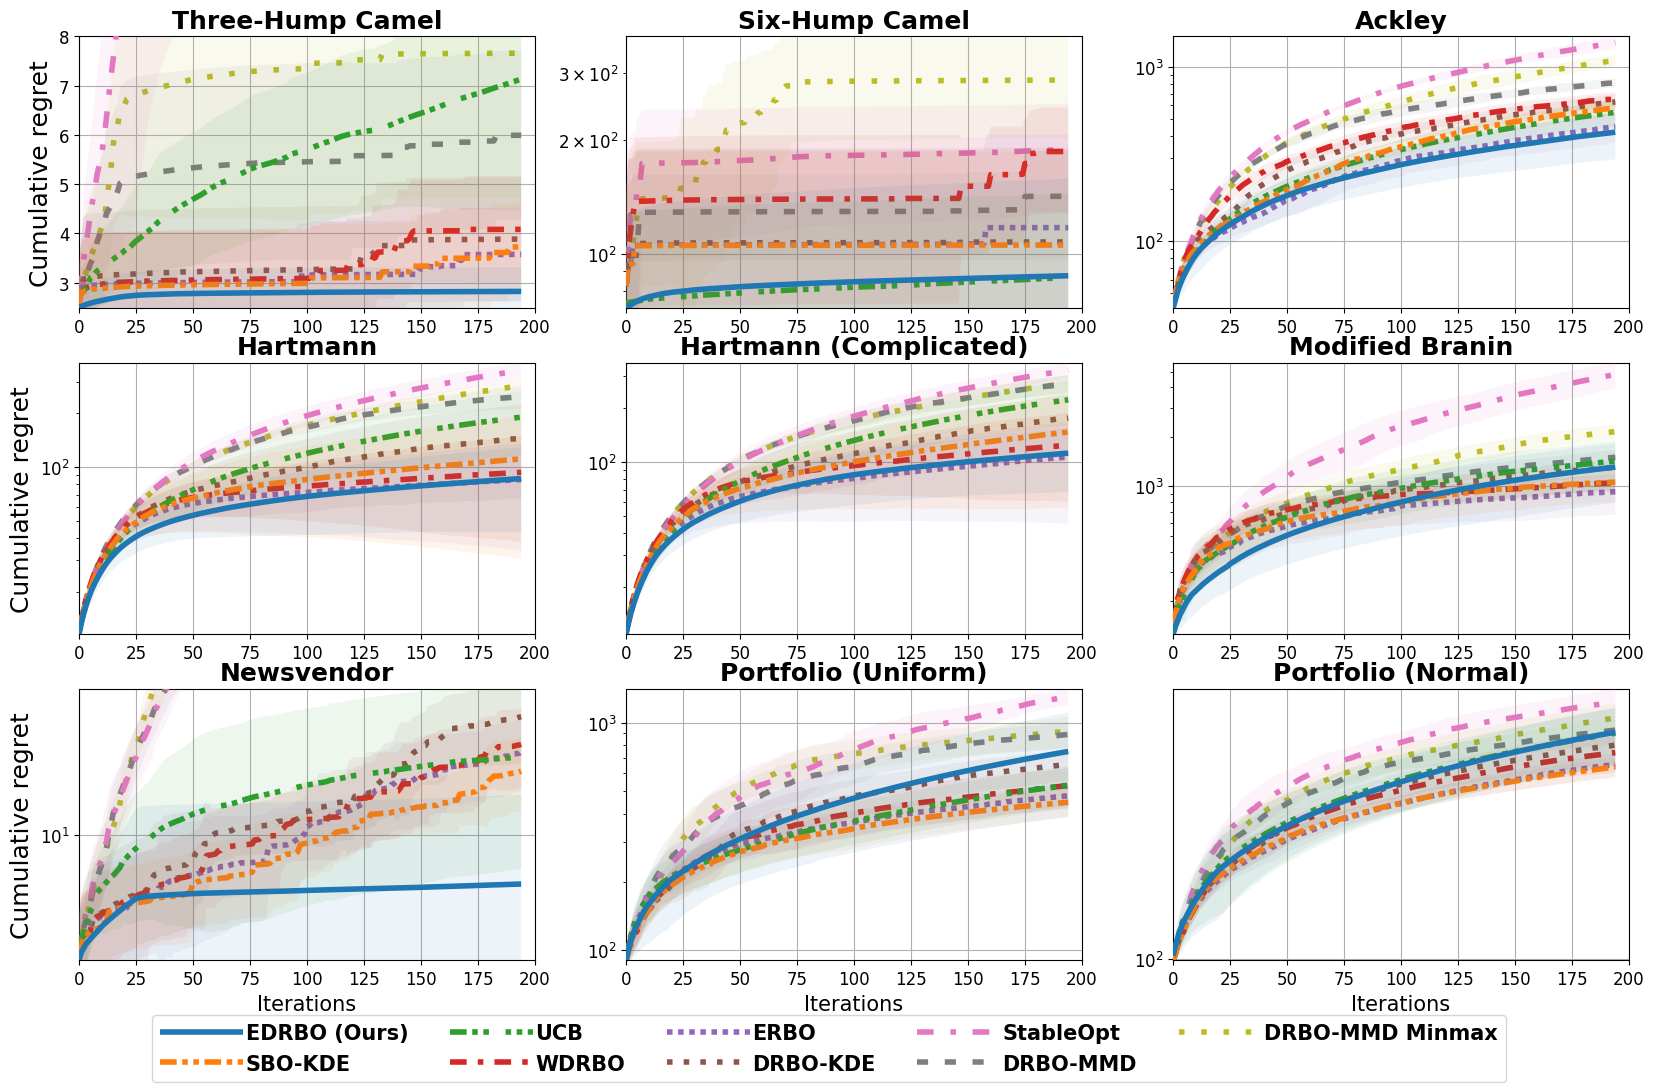

In [74]:
fig, ax = plt.subplots(ncols=3, nrows=3, figsize=(20, 12))

for i, f in enumerate(functions):
    
    ax_ = ax[i//3][i%3]
    
    mins, maxs = [], []
    
    for j, m in enumerate(models):
        
        res_i = res[f][m]
        
        z = 10 - j
        # print(z, method_to_name[m])
        
        # try:
        ax_.plot(res_i.mean(axis=0), label=method_to_name[m], zorder=z, linestyle=linestyles[m], linewidth=4)
        try:
            ax_.fill_between(np.arange(res_i.shape[1]),
                         res_i.mean(axis=0) - res_i.std(axis=0),
                         res_i.mean(axis=0) + res_i.std(axis=0), alpha=0.08, zorder=z)
        except:
            continue
        
        mins.append(np.min(res_i.mean(axis=0)))
        maxs.append(np.max(res_i.mean(axis=0) + res_i.std(axis=0)))
        
        # if i == 5:
        #     axins.plot(res_i.mean(axis=0), label=method_to_name[m])
        #     axins.fill_between(np.arange(res_i.shape[1]),
        #              res_i.mean(axis=0) - res_i.std(axis=0),
        #              res_i.mean(axis=0) + res_i.std(axis=0), alpha=0.08)
        
    
    ax_.set_title(name_to_title[f], fontsize=18, fontweight='bold')
    if i%3 == 0:
        ax_.set_ylabel('Cumulative regret', fontsize=18)#, fontweight='bold')
    if (i//3 == 2):
        ax_.set_xlabel('Iterations', fontsize=15)#, fontweight='bold')
    if (i != 0):
        ax_.set_yscale('log')
    ax_.grid(True)
    
    mms = np.max(maxs)
    
    if i == 0:
        mms = 8e0
    elif i == 6:
        mms = 2e1
    
    mns = np.min(mins)
    
    ax_.set_ylim(mns, mms)
    ax_.set_xlim(0, 200)
    
    if i == 6:
        ax_.set_yticks([1e1], [r'$10^{1}$'])
        ax_.minorticks_off()
    if i == 8:
        ax_.set_yticks([1e2], [r'$10^{2}$'])
        ax_.minorticks_off()

handles = [
    Line2D([3, 0], [3, 1],
           color=f'C{i}',
           linewidth=4.0,
           linestyle=linestyles[m],
           label=method_to_name[m])
    for i, m in enumerate(models)
]
# handles = [mpatches.Patch(color=f'C{i}', label=method_to_name[m]) for i, m in enumerate(models)]
# plt.legend(handles=handles, loc='lower center', prop={'weight':'bold', 'size': 14})
fig.legend(handles=handles,
           loc='lower center',
           ncol=5,
           prop={'weight': 'bold', 'size': 15},#
           bbox_to_anchor=(0.5, 0.0), handletextpad=0.1,
           handlelength=4,)

# plt.savefig("images/cumulative_regret_full.pdf", format="pdf", dpi=500, bbox_inches='tight', pad_inches=0)
plt.show()

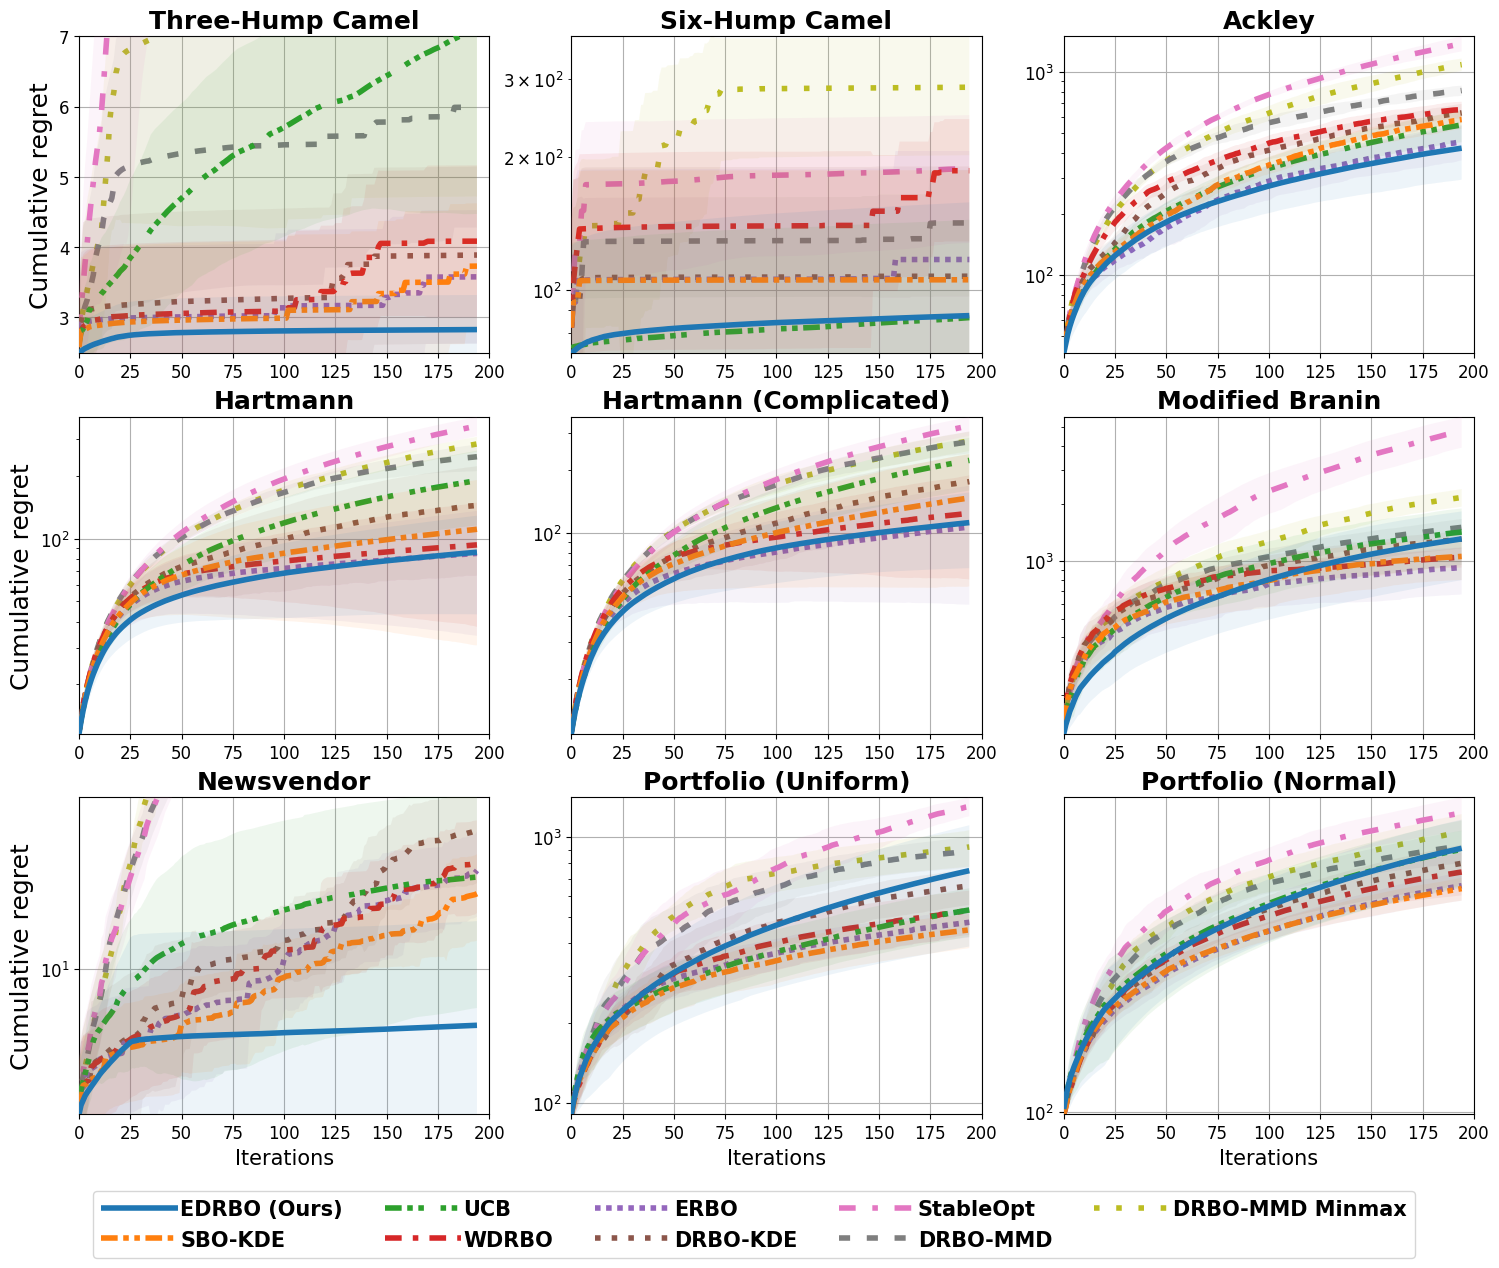

In [95]:
fig, ax = plt.subplots(ncols=3, nrows=3, figsize=(18, 14))

for i, f in enumerate(functions):
    
    ax_ = ax[i//3][i%3]
    
    mins, maxs = [], []
    # if i == 5:
    #     axins = ax_.inset_axes([0.5, 0.1, 0.4, 0.4])
    
    for j, m in enumerate(models):
        
        res_i = res[f][m]
        
        z = 10 - j
        # print(z, method_to_name[m])
        
        # try:
        ax_.plot(res_i.mean(axis=0), label=method_to_name[m], zorder=z, linestyle=linestyles[m], linewidth=4)
        try:
            ax_.fill_between(np.arange(res_i.shape[1]),
                         res_i.mean(axis=0) - res_i.std(axis=0),
                         res_i.mean(axis=0) + res_i.std(axis=0), alpha=0.08, zorder=z)
        except:
            continue
        
        mins.append(np.min(res_i.mean(axis=0)))
        maxs.append(np.max(res_i.mean(axis=0) + res_i.std(axis=0)))
        
        # if i == 5:
        #     axins.plot(res_i.mean(axis=0), label=method_to_name[m])
        #     axins.fill_between(np.arange(res_i.shape[1]),
        #              res_i.mean(axis=0) - res_i.std(axis=0),
        #              res_i.mean(axis=0) + res_i.std(axis=0), alpha=0.08)
        
    
    ax_.set_title(name_to_title[f], fontsize=18, fontweight='bold')
    if i%3 == 0:
        ax_.set_ylabel('Cumulative regret', fontsize=18)#, fontweight='bold')
    if (i//3 == 2):
        ax_.set_xlabel('Iterations', fontsize=15)#, fontweight='bold')
    if (i != 0):
        ax_.set_yscale('log')
    ax_.grid(True)
    
    mms = np.max(maxs)
    
    if i == 0:
        mms = 7e0
    elif i == 6:
        mms = 2e1
    
    mns = np.min(mins)
    
    ax_.set_ylim(mns, mms)
    ax_.set_xlim(0, 200)
    
    if i == 6:
        ax_.set_yticks([1e1], [r'$10^{1}$'])
        ax_.minorticks_off()
    if i == 8:
        ax_.set_yticks([1e2], [r'$10^{2}$'])
        ax_.minorticks_off()

handles = [
    Line2D([3, 0], [3, 1],
           color=f'C{i}',
           linewidth=4.0,
           linestyle=linestyles[m],
           label=method_to_name[m])
    for i, m in enumerate(models)
]
# handles = [mpatches.Patch(color=f'C{i}', label=method_to_name[m]) for i, m in enumerate(models)]
# plt.legend(handles=handles, loc='lower center', prop={'weight':'bold', 'size': 14})
fig.legend(handles=handles,
           loc='lower center',
           ncol=5,
           prop={'weight': 'bold', 'size': 15},#
           bbox_to_anchor=(0.5, 0.0), handletextpad=0.1,
           handlelength=3.69,)

plt.savefig("images/cumulative_regret_full.pdf", format="pdf", dpi=500, bbox_inches='tight', pad_inches=0)
plt.show()

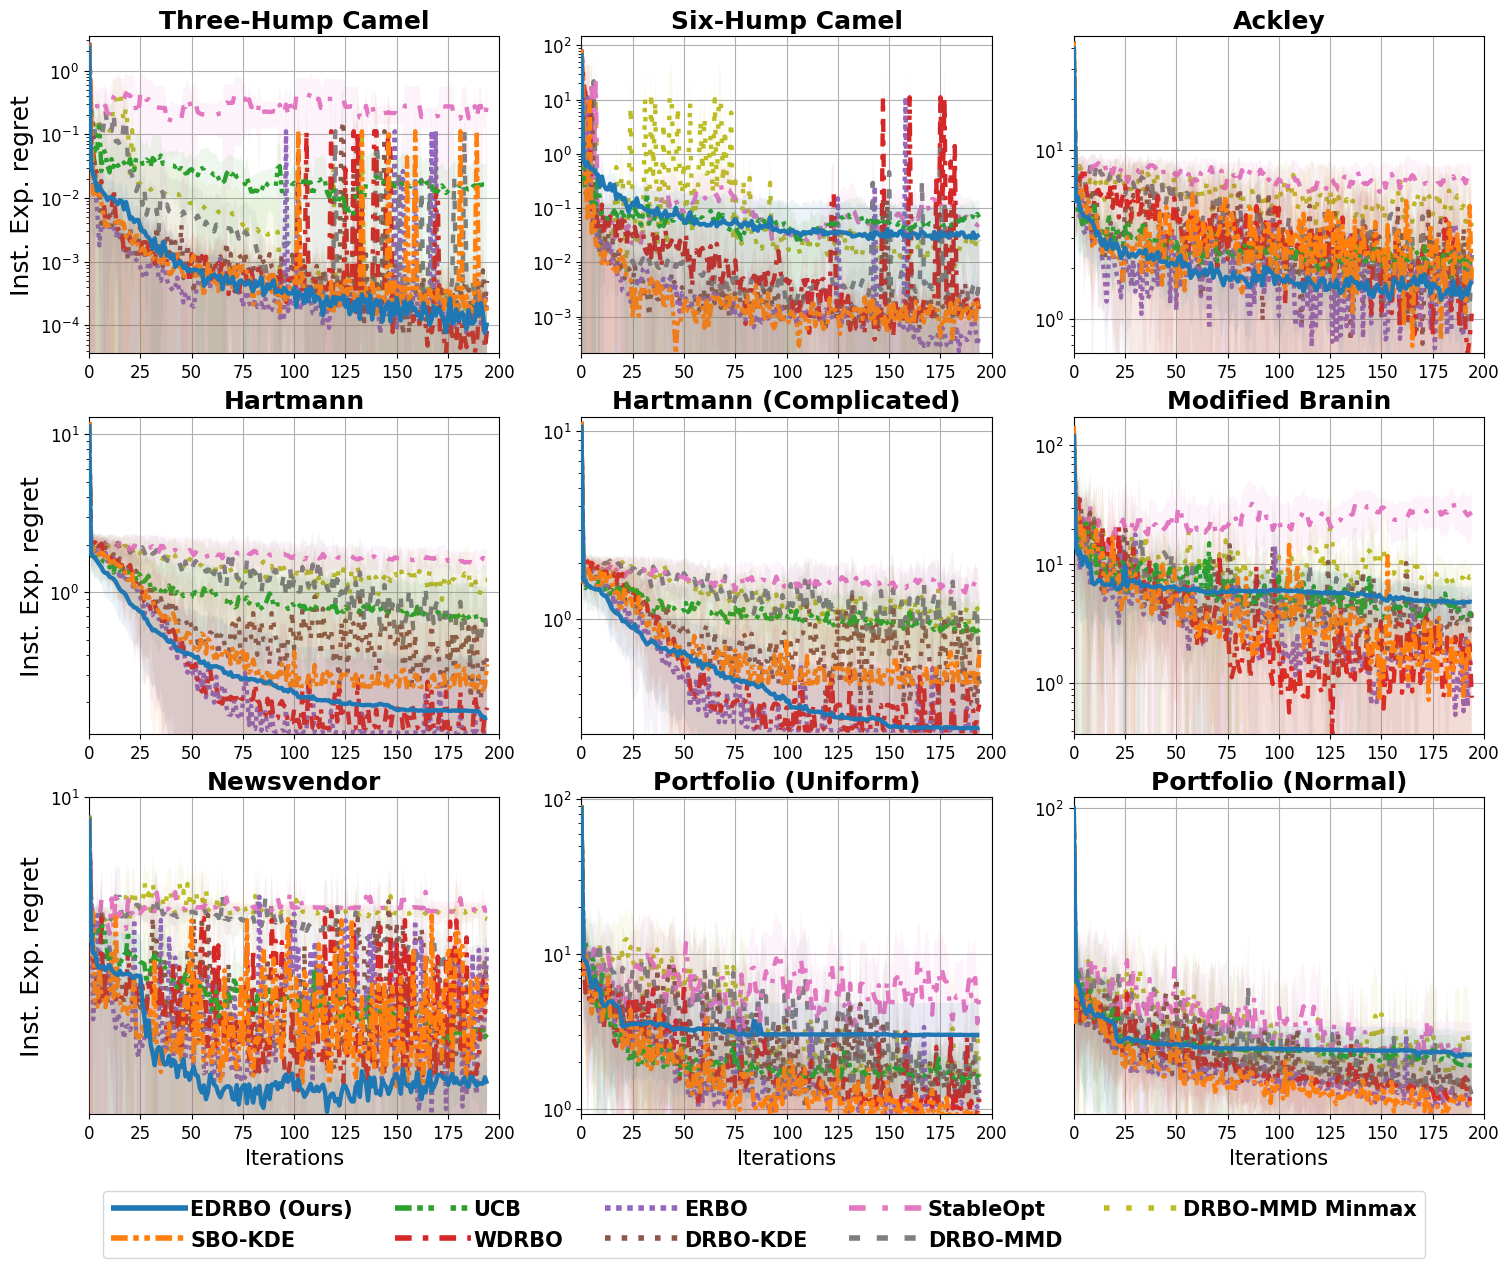

In [96]:
fig, ax = plt.subplots(ncols=3, nrows=3, figsize=(18, 14))

for i, f in enumerate(functions):
    
    ax_ = ax[i//3][i%3]
    
    mins, maxs = [], []
    # if i == 5:
    #     axins = ax_.inset_axes([0.5, 0.1, 0.4, 0.4])
    
    for j, m in enumerate(models):
        
        res_i = np.diff(res[f][m], prepend=0)
        
        z = 10 - j
        # print(z, method_to_name[m])
        
        # try:
        ax_.plot(res_i.mean(axis=0), label=method_to_name[m], zorder=z, linestyle=linestyles[m], linewidth=3.14)
        try:
            ax_.fill_between(np.arange(res_i.shape[1]),
                         res_i.mean(axis=0) - res_i.std(axis=0),
                         res_i.mean(axis=0) + res_i.std(axis=0), alpha=0.08, zorder=z)
        except:
            continue
        
        mins.append(np.min(res_i.mean(axis=0)))
        maxs.append(np.max(res_i.mean(axis=0) + res_i.std(axis=0)))
        
        # if i == 5:
        #     axins.plot(res_i.mean(axis=0), label=method_to_name[m])
        #     axins.fill_between(np.arange(res_i.shape[1]),
        #              res_i.mean(axis=0) - res_i.std(axis=0),
        #              res_i.mean(axis=0) + res_i.std(axis=0), alpha=0.08)
        
    
    ax_.set_title(name_to_title[f], fontsize=18, fontweight='bold')
    if i%3 == 0:
        ax_.set_ylabel('Inst. Exp. regret', fontsize=18)#, fontweight='bold')
    if (i//3 == 2):
        ax_.set_xlabel('Iterations', fontsize=15)#, fontweight='bold')
    # if (i != 0):
    ax_.set_yscale('log')
    ax_.grid(True)
    
    mms = np.max(maxs)
    
    # if i == 0:
    #     mms = 8e0
    # elif i == 6:
    #     mms = 2e1
    
    mns = np.min(mins)
    
    ax_.set_ylim(mns, mms)
    ax_.set_xlim(0, 200)
    
    if i == 6:
        ax_.set_yticks([1e1], [r'$10^{1}$'])
        ax_.minorticks_off()
    if i == 8:
        ax_.set_yticks([1e2], [r'$10^{2}$'])
        ax_.minorticks_off()

handles = [
    Line2D([3, 0], [3, 1],
           color=f'C{i}',
           linewidth=4.0,
           linestyle=linestyles[m],
           label=method_to_name[m])
    for i, m in enumerate(models)
]
# handles = [mpatches.Patch(color=f'C{i}', label=method_to_name[m]) for i, m in enumerate(models)]
# plt.legend(handles=handles, loc='lower center', prop={'weight':'bold', 'size': 14})
fig.legend(handles=handles,
           loc='lower center',
           ncol=5,
           prop={'weight': 'bold', 'size': 15},#
           bbox_to_anchor=(0.5, 0.0), handletextpad=0.1,
           handlelength=3.69,)

plt.savefig("images/instantaneous_expected_regret_full.pdf", format="pdf", dpi=500, bbox_inches='tight', pad_inches=0)
plt.show()